# POS Tagging with MLP

Task 3 of Assignment 2 — trains an MLP POS tagger using three embedding variants:
SVD, SkipGram (Word2Vec), and GloVe (pre-trained).

- Sliding-window input: concatenate embeddings of [w_{t-C}, ..., w_t, ..., w_{t+C}]
- At least 2 hidden layers with ReLU + Dropout
- Hyperparameter tuning on SkipGram embeddings, then best params applied to all 3
- Evaluation: Accuracy + Macro-F1 on test set; confusion matrix for best model

In [1]:
# keep the Kaggle session alive during long training runs
import threading
import time
import sys
from datetime import datetime

def keep_alive():
    while True:
        print(f"[KEEP ALIVE] {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        sys.stdout.flush()
        time.sleep(20 * 60)

thread = threading.Thread(target=keep_alive, daemon=True)
thread.start()

[KEEP ALIVE] 2026-03-02 19:28:02


In [2]:
import copy
import itertools
import json
import os
import random

import matplotlib.pyplot as plt
import nltk
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset

print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Torch version: 2.9.0+cu126
CUDA available: True


In [3]:
# -------------------------------------------------------
# Config — update the *_path entries to your Kaggle input
# dataset paths before running (e.g. /kaggle/input/<name>/...)
# -------------------------------------------------------
config = {
    'seed': 42,

    # paths to the embedding files uploaded as a Kaggle dataset
    'svd_path':          '/kaggle/input/datasets/mehraom/embeddings/svd.pt',
    'skipgram_path':     '/kaggle/input/datasets/mehraom/embeddings/skipgram.pt',
    'glove_txt_path':    '/kaggle/input/datasets/anmolkumar/glove-embeddings/glove.6B.300d.txt',
    'glove_pt_path':     'embeddings/glove.pt',   # converted .pt file (created by the next cell)

    # data split (must sum to 1)
    'train_ratio': 0.8,
    'val_ratio':   0.1,
    # remaining 10% becomes test

    # hyperparameter search space
    'window_sizes':   [1, 2],      # C in [w_{t-C},...,w_{t+C}]
    'hidden_sizes':   [256, 512],  # first hidden layer size (second = hidden//2)
    'learning_rates': [0.001, 0.003],
    'batch_sizes':    [256, 512],
    'dropout':        0.3,

    # epochs
    'tune_epochs':          10,
    'final_epochs':         20,
    'early_stop_patience':   3,

    # output
    'output_dir':      'pos_tagger',
    'results_json':    'pos_tuning_results.json',
    'checkpoint_json': 'pos_tuning_checkpoint.json',
    'resume_from_checkpoint': True,
}

config

{'seed': 42,
 'svd_path': '/kaggle/input/datasets/mehraom/embeddings/svd.pt',
 'skipgram_path': '/kaggle/input/datasets/mehraom/embeddings/skipgram.pt',
 'glove_txt_path': '/kaggle/input/datasets/anmolkumar/glove-embeddings/glove.6B.300d.txt',
 'glove_pt_path': 'embeddings/glove.pt',
 'train_ratio': 0.8,
 'val_ratio': 0.1,
 'window_sizes': [1, 2],
 'hidden_sizes': [256, 512],
 'learning_rates': [0.001, 0.003],
 'batch_sizes': [256, 512],
 'dropout': 0.3,
 'tune_epochs': 10,
 'final_epochs': 20,
 'early_stop_patience': 3,
 'output_dir': 'pos_tagger',
 'results_json': 'pos_tuning_results.json',
 'checkpoint_json': 'pos_tuning_checkpoint.json',
 'resume_from_checkpoint': True}

In [4]:
# -------------------------------------------------------
# Convert glove.6B.300d.txt -> glove.pt
# Same format as svd.pt / skipgram.pt:
#   { 'embeddings': FloatTensor, 'word2idx': dict, 'idx2word': dict }
# Run this cell once; subsequent cells load from glove_pt_path.
# -------------------------------------------------------
def convert_glove_txt_to_pt(txt_path, pt_path):
    if os.path.exists(pt_path):
        print(f"glove.pt already exists at {pt_path}, skipping conversion.")
        return

    print(f"Reading {txt_path} ...")
    raw = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            raw[parts[0]] = np.array(parts[1:], dtype=np.float32)

    emb_dim  = next(iter(raw.values())).shape[0]
    word2idx = {w: i for i, w in enumerate(sorted(raw.keys()))}
    idx2word = {i: w for w, i in word2idx.items()}

    matrix = np.zeros((len(word2idx), emb_dim), dtype=np.float32)
    for word, idx in word2idx.items():
        matrix[idx] = raw[word]

    os.makedirs(os.path.dirname(pt_path) or '.', exist_ok=True)
    torch.save({
        'embeddings': torch.FloatTensor(matrix),
        'word2idx':   word2idx,
        'idx2word':   idx2word,
        'meta': {'source': txt_path, 'dim': emb_dim, 'vocab': len(word2idx)},
    }, pt_path)
    print(f"Saved -> {pt_path}  (vocab={len(word2idx)}, dim={emb_dim})")


convert_glove_txt_to_pt(config['glove_txt_path'], config['glove_pt_path'])

Reading /kaggle/input/datasets/anmolkumar/glove-embeddings/glove.6B.300d.txt ...
Saved -> embeddings/glove.pt  (vocab=400000, dim=300)


In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_pos_data(seed, train_ratio, val_ratio):
    nltk.download('brown', quiet=True)
    nltk.download('universal_tagset', quiet=True)
    from nltk.corpus import brown

    # load sentences with the simplified 12-tag universal tagset
    tagged_sents = brown.tagged_sents(tagset='universal')

    # keep only alphabetic tokens (lowercase), same filter as SVD/Word2Vec notebooks
    filtered_sents = []
    for sent in tagged_sents:
        filtered = [(w.lower(), t) for w, t in sent if w.isalpha()]
        if filtered:
            filtered_sents.append(filtered)

    # build POS tag vocab
    all_tags = sorted(set(t for sent in filtered_sents for _, t in sent))
    tag2idx = {t: i for i, t in enumerate(all_tags)}
    idx2tag = {i: t for t, i in tag2idx.items()}

    # shuffle sentences and split 80/10/10
    ids = list(range(len(filtered_sents)))
    random.Random(seed).shuffle(ids)

    n = len(ids)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    train_sents = [filtered_sents[i] for i in ids[:n_train]]
    val_sents   = [filtered_sents[i] for i in ids[n_train:n_train + n_val]]
    test_sents  = [filtered_sents[i] for i in ids[n_train + n_val:]]

    print(f"Sentences  -> train: {len(train_sents)} | val: {len(val_sents)} | test: {len(test_sents)}")
    print(f"Tags ({len(all_tags)}): {all_tags}")

    return train_sents, val_sents, test_sents, tag2idx, idx2tag


set_seed(config['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

train_sents, val_sents, test_sents, tag2idx, idx2tag = load_pos_data(
    config['seed'], config['train_ratio'], config['val_ratio']
)
num_tags = len(tag2idx)

Device: cuda
Sentences  -> train: 45412 | val: 5676 | test: 5678
Tags (11): ['ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']


In [6]:
# all three loaders now follow the same pattern: load .pt -> (numpy matrix, word2idx)

def load_embedding_pt(path, name):
    data = torch.load(path, map_location='cpu', weights_only = False)
    vectors  = data['embeddings'].numpy()
    word2idx = data['word2idx']
    print(f"{name:<10}: vocab={len(word2idx):>6}, dim={vectors.shape[1]}")
    return vectors, word2idx


def build_embedding_matrix(vectors, word2idx, device):
    # append a zero row as the PAD / OOV embedding (index = len(word2idx))
    pad_row = np.zeros((1, vectors.shape[1]), dtype=np.float32)
    full    = np.vstack([vectors, pad_row])
    mat     = torch.FloatTensor(full).to(device)
    mat.requires_grad_(False)  # embeddings are frozen
    return mat


svd_vectors,   svd_word2idx   = load_embedding_pt(config['svd_path'],      'SVD')
sg_vectors,    sg_word2idx    = load_embedding_pt(config['skipgram_path'],  'SkipGram')
glove_vectors, glove_word2idx = load_embedding_pt(config['glove_pt_path'],  'GloVe')

embeddings = {
    'glove':    (glove_vectors, glove_word2idx),
    'svd':      (svd_vectors,   svd_word2idx),
    'skipgram': (sg_vectors,    sg_word2idx),
}

SVD       : vocab= 15551, dim=300
SkipGram  : vocab= 15551, dim=100
GloVe     : vocab=400000, dim=300


In [7]:
def build_windows(sents, word2idx, tag2idx, window_size):
    """
    For each word in each sentence build a context window of length (2*C+1).
    Boundary positions and OOV words both use PAD_IDX (= len(word2idx)).
    Returns LongTensors: windows (N, 2C+1) and tags (N,).
    """
    PAD_IDX = len(word2idx)
    all_windows = []
    all_tags    = []

    for sent in sents:
        words = [w for w, _ in sent]
        tags  = [t for _, t in sent]
        n = len(words)

        for i in range(n):
            ctx = []
            for offset in range(-window_size, window_size + 1):
                j = i + offset
                if j < 0 or j >= n:
                    ctx.append(PAD_IDX)
                else:
                    ctx.append(word2idx.get(words[j], PAD_IDX))
            all_windows.append(ctx)
            all_tags.append(tag2idx[tags[i]])

    return torch.LongTensor(all_windows), torch.LongTensor(all_tags)


class POSDataset(Dataset):
    def __init__(self, windows, tags):
        self.windows = windows
        self.tags    = tags

    def __len__(self):
        return len(self.tags)

    def __getitem__(self, idx):
        return self.windows[idx], self.tags[idx]

In [8]:
class MLPTagger(nn.Module):
    """
    Two hidden-layer MLP for POS tagging.
    Input  : concatenated window embeddings -> (2C+1) * emb_dim
    Hidden : hidden_size  -> hidden_size//2 (both ReLU + Dropout)
    Output : num_tags logits (CrossEntropyLoss applied outside)
    """
    def __init__(self, input_size, hidden_size, num_tags, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_tags),
        )

    def forward(self, x):
        return self.net(x)

In [9]:
def run_epoch(model, loader, emb_matrix, optimizer, criterion, device, train_mode):
    model.train() if train_mode else model.eval()
    total_loss  = 0.0
    num_batches = 0

    with torch.set_grad_enabled(train_mode):
        for windows, tags in loader:
            windows = windows.to(device)
            tags    = tags.to(device)

            # look up frozen embeddings and flatten into a single vector
            x = emb_matrix[windows]              # (B, 2C+1, emb_dim)
            x = x.view(windows.size(0), -1)      # (B, (2C+1)*emb_dim)

            logits = model(x)
            loss   = criterion(logits, tags)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss  += loss.item()
            num_batches += 1

    return total_loss / max(1, num_batches)


def train_with_early_stopping(
    model, optimizer, criterion,
    train_loader, val_loader,
    emb_matrix, device,
    max_epochs, patience
):
    best_val   = float('inf')
    best_state = None
    wait       = 0
    train_hist = []
    val_hist   = []

    for epoch in range(max_epochs):
        train_loss = run_epoch(model, train_loader, emb_matrix, optimizer, criterion, device, True)
        val_loss   = run_epoch(model, val_loader,   emb_matrix, optimizer, criterion, device, False)

        train_hist.append(train_loss)
        val_hist.append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait       = 0
        else:
            wait += 1

        print(f"  Epoch {epoch+1:>2}/{max_epochs} | train={train_loss:.4f} | val={val_loss:.4f}")

        if wait >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_hist, val_hist, best_val, len(train_hist)


# --- checkpoint helpers (same pattern as word2vec notebook) ---

def cfg_key(emb_name, window_size, hidden_size, lr, batch_size):
    return f"{emb_name}|win={window_size}|h={hidden_size}|lr={lr}|bs={batch_size}"

def save_checkpoint(path, results, best):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump({'all_results': results, 'best': best}, f, indent=2)

def load_checkpoint(path):
    if not os.path.exists(path):
        return [], None
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    return data.get('all_results', []), data.get('best', None)

def recompute_best(results):
    if not results:
        return None
    return min(results, key=lambda x: x['val_loss_best'])

In [10]:
# -------------------------------------------------------
# Hyperparameter tuning — runs for all 3 embeddings.
# Grid: window x hidden x lr x batch_size
# Best config is selected per embedding.
# -------------------------------------------------------
criterion = nn.CrossEntropyLoss()

if config['resume_from_checkpoint']:
    tuning_results, _ = load_checkpoint(config['checkpoint_json'])
    if tuning_results:
        print(f"Loaded checkpoint: {len(tuning_results)} completed configs")
    else:
        print('No checkpoint found, starting fresh')
else:
    tuning_results = []

completed_keys = {
    cfg_key(r['emb_name'], r['window_size'], r['hidden_size'], r['lr'], r['batch_size'])
    for r in tuning_results
}

all_combos = list(itertools.product(
    config['window_sizes'],
    config['hidden_sizes'],
    config['learning_rates'],
    config['batch_sizes'],
))
print(f"Configs per embedding: {len(all_combos)} | Total: {len(all_combos) * len(embeddings)}")
print(f"Already completed: {len(completed_keys)}")

for emb_name, (vectors, word2idx) in embeddings.items():
    emb_matrix = build_embedding_matrix(vectors, word2idx, device)
    emb_dim    = vectors.shape[1]

    print(f"\n{'='*55}")
    print(f"Tuning [{emb_name}]  dim={emb_dim}")
    print('='*55)

    for window_size, hidden_size, lr, batch_size in all_combos:
        key = cfg_key(emb_name, window_size, hidden_size, lr, batch_size)
        if key in completed_keys:
            print(f"  Skipping: {key}")
            continue

        print(f"\n  --- {key} ---")

        train_w, train_t = build_windows(train_sents, word2idx, tag2idx, window_size)
        val_w,   val_t   = build_windows(val_sents,   word2idx, tag2idx, window_size)

        train_loader = DataLoader(POSDataset(train_w, train_t), batch_size=batch_size, shuffle=True,  drop_last=True)
        val_loader   = DataLoader(POSDataset(val_w,   val_t),   batch_size=batch_size, shuffle=False)

        input_size = (2 * window_size + 1) * emb_dim
        model      = MLPTagger(input_size, hidden_size, num_tags, config['dropout']).to(device)
        optimizer  = torch.optim.Adam(model.parameters(), lr=lr)

        train_hist, val_hist, best_val, epochs_run = train_with_early_stopping(
            model, optimizer, criterion,
            train_loader, val_loader,
            emb_matrix, device,
            config['tune_epochs'], config['early_stop_patience'],
        )

        result = {
            'emb_name':        emb_name,
            'window_size':     window_size,
            'hidden_size':     hidden_size,
            'lr':              lr,
            'batch_size':      batch_size,
            'dropout':         config['dropout'],
            'epochs_run':      epochs_run,
            'val_loss_best':   best_val,
            'train_loss_last': train_hist[-1],
            'train_hist':      train_hist,
            'val_hist':        val_hist,
        }
        tuning_results.append(result)
        completed_keys.add(key)

        # save checkpoint after every config
        best_per_emb = {
            name: recompute_best([r for r in tuning_results if r['emb_name'] == name])
            for name in embeddings
        }
        save_checkpoint(config['checkpoint_json'], tuning_results, best_per_emb)
        with open(config['results_json'], 'w', encoding='utf-8') as f:
            json.dump({'best_per_emb': best_per_emb, 'all_results': tuning_results}, f, indent=2)

# best config per embedding
best_per_emb = {
    name: recompute_best([r for r in tuning_results if r['emb_name'] == name])
    for name in embeddings
}

print("\nBest config per embedding:")
for name, b in best_per_emb.items():
    print(f"  [{name}]  window={b['window_size']} hidden={b['hidden_size']} "
          f"lr={b['lr']} bs={b['batch_size']}  val_loss={b['val_loss_best']:.4f}")

No checkpoint found, starting fresh
Configs per embedding: 16 | Total: 48
Already completed: 0

Tuning [glove]  dim=300

  --- glove|win=1|h=256|lr=0.001|bs=256 ---
  Epoch  1/10 | train=0.2637 | val=0.1321
  Epoch  2/10 | train=0.1440 | val=0.1106
  Epoch  3/10 | train=0.1250 | val=0.1038
  Epoch  4/10 | train=0.1145 | val=0.0973
  Epoch  5/10 | train=0.1076 | val=0.0947
  Epoch  6/10 | train=0.1014 | val=0.0958
  Epoch  7/10 | train=0.0977 | val=0.0950
  Epoch  8/10 | train=0.0945 | val=0.0933
  Epoch  9/10 | train=0.0912 | val=0.0936
  Epoch 10/10 | train=0.0889 | val=0.0919

  --- glove|win=1|h=256|lr=0.001|bs=512 ---
  Epoch  1/10 | train=0.3049 | val=0.1347
  Epoch  2/10 | train=0.1482 | val=0.1099
  Epoch  3/10 | train=0.1252 | val=0.1038
  Epoch  4/10 | train=0.1136 | val=0.0981
  Epoch  5/10 | train=0.1060 | val=0.0962
  Epoch  6/10 | train=0.1004 | val=0.0944
  Epoch  7/10 | train=0.0956 | val=0.0928
  Epoch  8/10 | train=0.0920 | val=0.0913
  Epoch  9/10 | train=0.0884 | val

In [11]:
# -------------------------------------------------------
# Final training — each embedding uses its own best config
# from tuning. Embeddings are kept frozen throughout.
# -------------------------------------------------------
os.makedirs(config['output_dir'], exist_ok=True)

final_models  = {}
final_results = {}

for emb_name, (vectors, word2idx) in embeddings.items():
    best = best_per_emb[emb_name]

    best_window = best['window_size']
    best_hidden = best['hidden_size']
    best_lr     = best['lr']
    best_bs     = best['batch_size']

    print(f"\n{'='*50}")
    print(f"Final training  [{emb_name}]  dim={vectors.shape[1]}")
    print(f"  window={best_window} | hidden={best_hidden} | lr={best_lr} | bs={best_bs}")
    print('='*50)

    emb_matrix = build_embedding_matrix(vectors, word2idx, device)
    emb_dim    = vectors.shape[1]
    input_size = (2 * best_window + 1) * emb_dim

    train_w, train_t = build_windows(train_sents, word2idx, tag2idx, best_window)
    val_w,   val_t   = build_windows(val_sents,   word2idx, tag2idx, best_window)
    test_w,  test_t  = build_windows(test_sents,  word2idx, tag2idx, best_window)

    train_loader = DataLoader(POSDataset(train_w, train_t), batch_size=best_bs, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(POSDataset(val_w,   val_t),   batch_size=best_bs, shuffle=False)
    test_loader  = DataLoader(POSDataset(test_w,  test_t),  batch_size=512,     shuffle=False)

    model     = MLPTagger(input_size, best_hidden, num_tags, config['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

    train_hist, val_hist, best_val, epochs_run = train_with_early_stopping(
        model, optimizer, criterion,
        train_loader, val_loader,
        emb_matrix, device,
        config['final_epochs'], config['early_stop_patience'],
    )

    final_models[emb_name]  = (model, emb_matrix, test_loader)
    final_results[emb_name] = {
        'val_loss':   best_val,
        'epochs_run': epochs_run,
        'train_hist': train_hist,
        'val_hist':   val_hist,
    }

    out_path = os.path.join(config['output_dir'], f'pos_tagger_{emb_name}.pt')
    torch.save({
        'model_state': model.state_dict(),
        'tag2idx':     tag2idx,
        'idx2tag':     idx2tag,
        'params': {
            'window_size': best_window,
            'hidden_size': best_hidden,
            'dropout':     config['dropout'],
            'lr':          best_lr,
            'batch_size':  best_bs,
            'emb_dim':     emb_dim,
            'input_size':  input_size,
            'num_tags':    num_tags,
        },
    }, out_path)
    print(f"  Saved -> {out_path}")


Final training  [glove]  dim=300
  window=1 | hidden=512 | lr=0.001 | bs=256
  Epoch  1/20 | train=0.2215 | val=0.1163
  Epoch  2/20 | train=0.1206 | val=0.1022
  Epoch  3/20 | train=0.1029 | val=0.0959
  Epoch  4/20 | train=0.0919 | val=0.0919
  Epoch  5/20 | train=0.0843 | val=0.0918
  Epoch  6/20 | train=0.0790 | val=0.0882
  Epoch  7/20 | train=0.0745 | val=0.0916
  Epoch  8/20 | train=0.0704 | val=0.0932
  Epoch  9/20 | train=0.0675 | val=0.0906
  Early stopping at epoch 9
  Saved -> pos_tagger/pos_tagger_glove.pt

Final training  [svd]  dim=300
  window=1 | hidden=512 | lr=0.001 | bs=512
  Epoch  1/20 | train=0.2769 | val=0.1973
  Epoch  2/20 | train=0.1956 | val=0.1758
  Epoch  3/20 | train=0.1748 | val=0.1678
  Epoch  4/20 | train=0.1613 | val=0.1600
  Epoch  5/20 | train=0.1515 | val=0.1544
  Epoch  6/20 | train=0.1433 | val=0.1527
  Epoch  7/20 | train=0.1376 | val=0.1518
[KEEP ALIVE] 2026-03-02 20:48:02
  Epoch  8/20 | train=0.1319 | val=0.1492
  Epoch  9/20 | train=0.1274 

Embedding      Accuracy   Macro-F1
-----------------------------------
glove            0.9743     0.9409
svd              0.9527     0.8941
skipgram         0.9629     0.9106

Best model: glove (accuracy=0.9743)


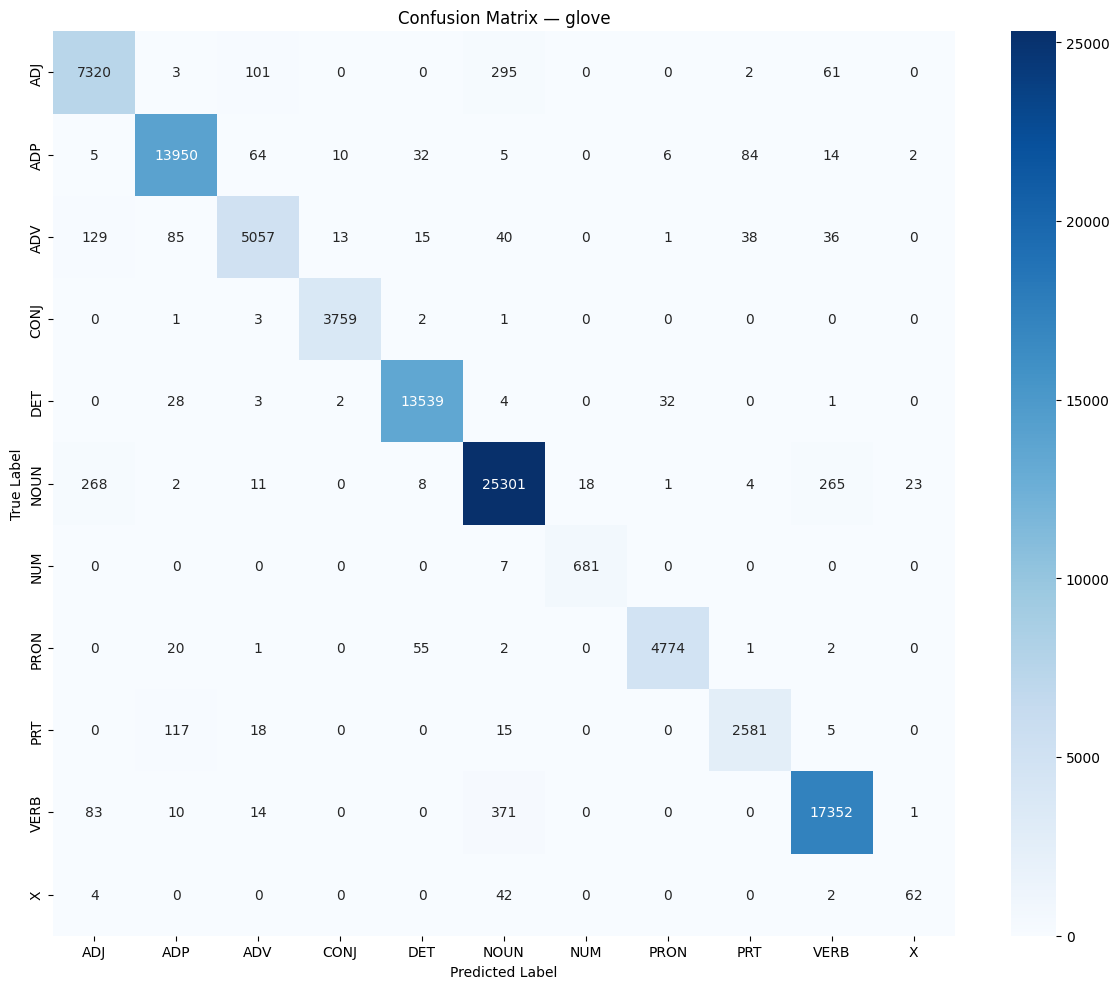

In [12]:
def evaluate(model, loader, emb_matrix, device):
    model.eval()
    all_preds = []
    all_true  = []

    with torch.no_grad():
        for windows, tags in loader:
            windows = windows.to(device)
            x       = emb_matrix[windows].view(windows.size(0), -1)
            preds   = model(x).argmax(dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_true.extend(tags.tolist())

    acc = accuracy_score(all_true, all_preds)
    f1  = f1_score(all_true, all_preds, average='macro')
    return acc, f1, all_true, all_preds


# evaluate all three models on the test set
print(f"{'Embedding':<12} {'Accuracy':>10} {'Macro-F1':>10}")
print('-' * 35)

best_acc      = -1.0
best_emb_name = None

for emb_name, (model, emb_matrix, test_loader) in final_models.items():
    acc, f1, all_true, all_preds = evaluate(model, test_loader, emb_matrix, device)
    final_results[emb_name]['accuracy']  = acc
    final_results[emb_name]['macro_f1']  = f1
    final_results[emb_name]['all_true']  = all_true
    final_results[emb_name]['all_preds'] = all_preds
    print(f"{emb_name:<12} {acc:>10.4f} {f1:>10.4f}")

    if acc > best_acc:
        best_acc      = acc
        best_emb_name = emb_name

print(f"\nBest model: {best_emb_name} (accuracy={best_acc:.4f})")


# confusion matrix for best model
cm        = confusion_matrix(final_results[best_emb_name]['all_true'],
                              final_results[best_emb_name]['all_preds'])
tag_names = [idx2tag[i] for i in range(num_tags)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=tag_names, yticklabels=tag_names,
            cmap='Blues')
plt.title(f'Confusion Matrix — {best_emb_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(config['output_dir'], f'confusion_matrix_{best_emb_name}.png'), dpi=150)
plt.show()

In [13]:
# save a concise JSON summary (exclude the raw prediction lists)
summary = {
    'best_hyperparameters_per_emb': best_per_emb,
    'test_results': {
        emb: {k: v for k, v in r.items() if k not in ('all_true', 'all_preds', 'train_hist', 'val_hist')}
        for emb, r in final_results.items()
    }
}

summary_path = os.path.join(config['output_dir'], 'final_results.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary -> {summary_path}")
print("\nTest results:")
for emb, r in summary['test_results'].items():
    print(f"  {emb:<10} accuracy={r['accuracy']:.4f}  macro_f1={r['macro_f1']:.4f}")

Saved summary -> pos_tagger/final_results.json

Test results:
  glove      accuracy=0.9743  macro_f1=0.9409
  svd        accuracy=0.9527  macro_f1=0.8941
  skipgram   accuracy=0.9629  macro_f1=0.9106


In [14]:
print('work finished')
# Download from Kaggle Output panel:
#   pos_tagger/pos_tagger_svd.pt
#   pos_tagger/pos_tagger_skipgram.pt
#   pos_tagger/pos_tagger_glove.pt
#   pos_tagger/confusion_matrix_<best>.png
#   pos_tagger/final_results.json
#   pos_tuning_results.json
#   pos_tuning_checkpoint.json

work finished
